<a href="https://colab.research.google.com/github/RMoulla/PYK_Mai/blob/main/Notebook_Introduction_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction à SARIMA

Ce notebook propose une introduction progressive au modèle **SARIMA** pour les séries temporelles saisonnières.

## ARIMA à SARIMA

Un modèle **ARIMA** permet de capturer à la fois les variations locales et la tendance. Il s'écrit généralement :

\[
ARIMA(p, d, q)
\]

avec :

- \(p\) : combien de valeurs passées de la série on utilise pour faire la prévision ;
- \(d\) : combien de fois on transforme la série pour supprimer la tendance et la rendre plus stable ;
- \(q\) : combien d'erreurs de prévision passées on utilise pour améliorer la prévision.


Un modèle **SARIMA** ajoute une composante saisonnière :

\[
SARIMA(p,d,q)(P,D,Q)_s
\]

avec :

- \(P\) : combien de valeurs des saisons précédentes on utilise (par exemple les mêmes mois des années précédentes) ;
- \(D\) : combien de différenciations saisonnières on applique pour supprimer la saisonnalité ;
- \(Q\) : combien d'erreurs saisonnières passées on utilise ;
- \(s\) : longueur de la saisonnalité (12 pour des données mensuelles avec une saisonnalité annuelle).

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import get_rdataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## Jeu de données AirPassenger

Le jeu de données **AirPassengers** est un jeu de données historique très utilisé pour l'apprentissage des modèles de séries temporelles. Il contient le nombre mensuel de passagers transportés par une compagnie aérienne internationale entre janvier 1949 et décembre 1960, soit 144 observations. Cette série présente deux caractéristiques importantes : une tendance croissante, qui traduit l'augmentation du trafic aérien au fil du temps, et une forte saisonnalité annuelle, avec des pics récurrents à certaines périodes de l'année. Ces propriétés en font un excellent exemple pour illustrer l'utilisation des modèles SARIMA, conçus pour modéliser simultanément les tendances et les comportements saisonniers des séries temporelles.

In [ ]:
# Chargement du dataset AirPassengers
data = get_rdataset("AirPassengers").data

# Création d'une série temporelle mensuelle
dates = pd.date_range(start="1949-01-01", periods=len(data), freq="MS")

series = pd.Series(
    data["value"].values,
    index=dates,
    name="passengers"
)

series.head()

1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: passengers, dtype: int64

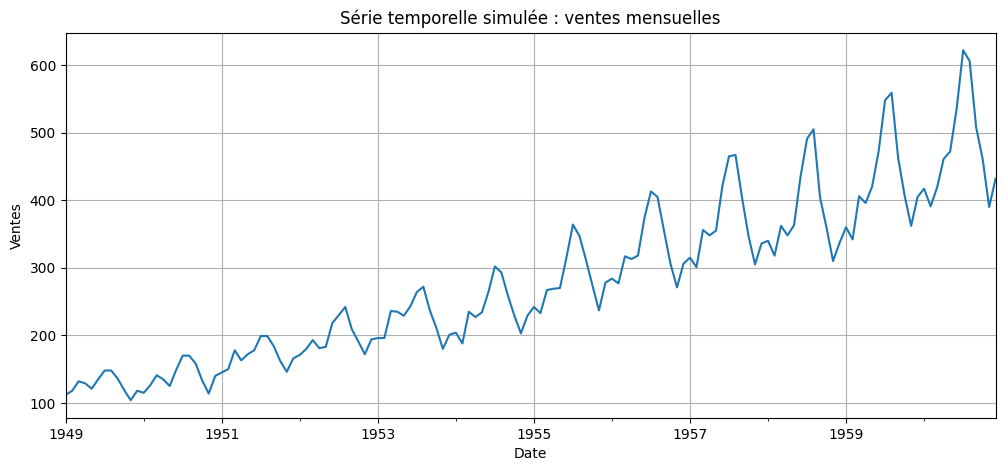

In [ ]:
series.plot(title="Série temporelle simulée : ventes mensuelles")
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.show()

## Découpage train / test

Pour évaluer un modèle de série temporelle, il ne faut pas mélanger aléatoirement les observations.

On entraîne le modèle sur le passé, puis on teste sa capacité à prévoir les périodes futures.

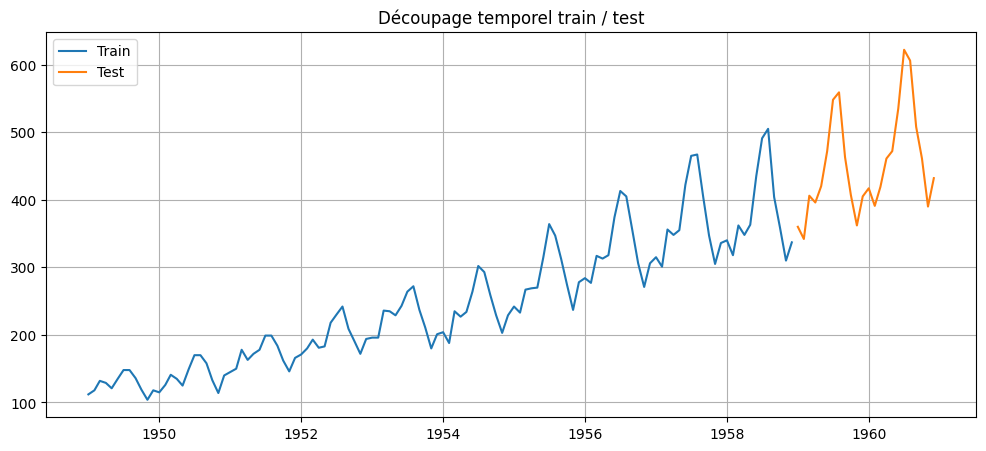

In [ ]:
train = series.iloc[:-24]
test = series.iloc[-24:]

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Découpage temporel train / test")
plt.legend()
plt.show()

## Différenciation simple et saisonnière

La différenciation simple retire une partie de la tendance :

\[
y'_t = y_t - y_{t-1}
\]

La différenciation saisonnière compare une observation à celle de la saison précédente :

\[
y'_t = y_t - y_{t-s}
\]

Pour une série mensuelle avec saisonnalité annuelle, on utilise souvent \(s=12\).

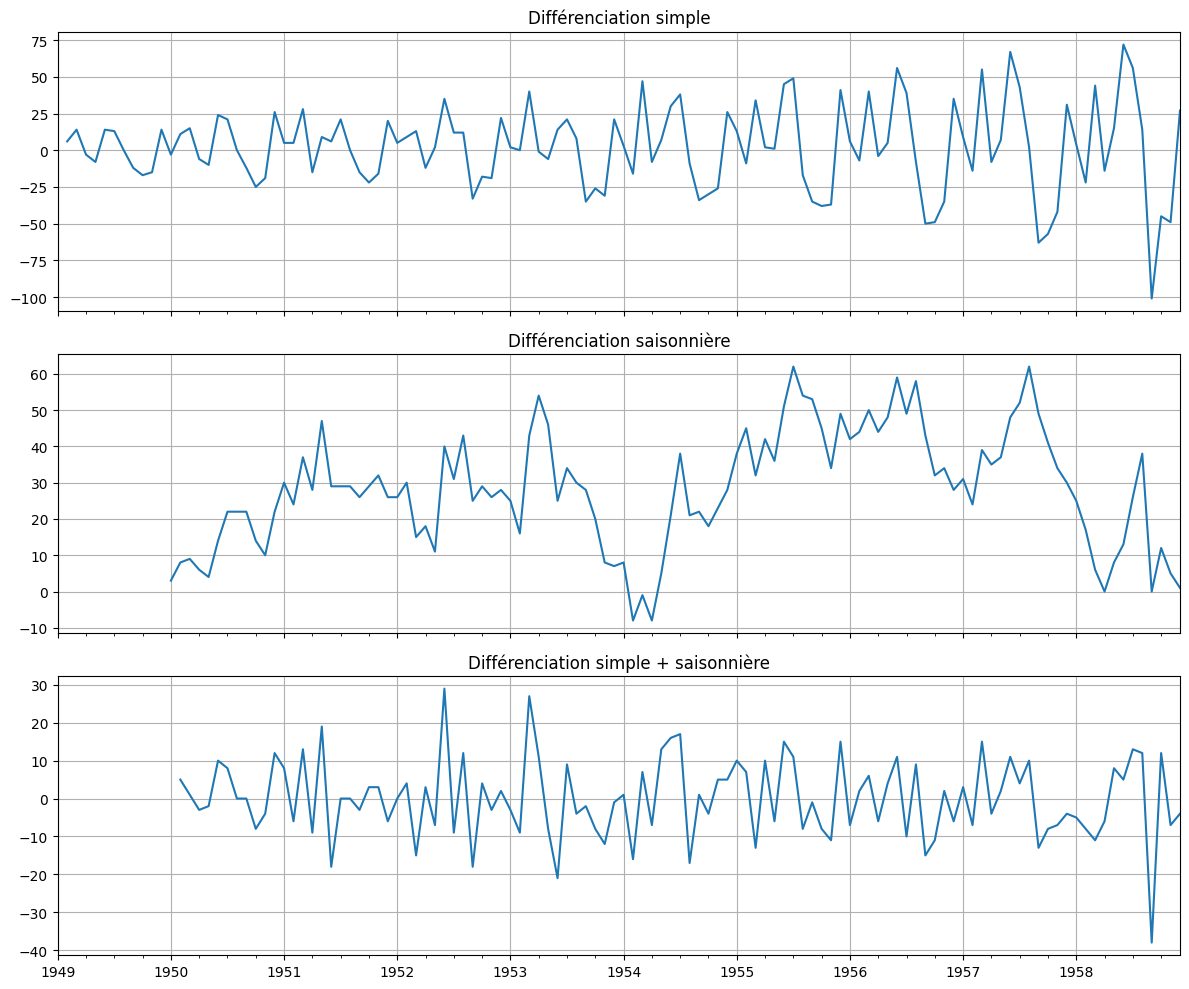

In [ ]:
diff_1 = train.diff()
diff_seasonal = train.diff(12)
diff_both = train.diff().diff(12)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
diff_1.plot(ax=axes[0], title="Différenciation simple")
diff_seasonal.plot(ax=axes[1], title="Différenciation saisonnière")
diff_both.plot(ax=axes[2], title="Différenciation simple + saisonnière")
plt.tight_layout()
plt.show()

In [ ]:
adf_test(diff_both, "série différenciée simple + saisonnière")

Test ADF : série différenciée simple + saisonnière
Statistique ADF : -13.0519
p-value : 0.0000
Valeurs critiques :
  1%: -3.4936
  5%: -2.8892
  10%: -2.5815


## Entraînement d'un modèle SARIMA

On utilise `SARIMAX` de `statsmodels`.  
Même si la classe s'appelle SARIMAX, elle permet d'entraîner un SARIMA lorsqu'on n'ajoute pas de variables exogènes.

In [ ]:
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -348.860
Date:                            Thu, 04 Jun 2026   AIC                            707.720
Time:                                    06:42:48   BIC                            720.383
Sample:                                01-01-1949   HQIC                           712.833
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4557      0.436     -1.044      0.296      -1.311       0.400
ma.L1          0.2194      0.458   

Les résultats montrent que les paramètres saisonniers sont significatifs.

- `ar.S.L12` a une p-value proche de 0 : cela signifie que la valeur observée il y a 12 mois aide à expliquer la valeur actuelle.
- `ma.S.L12` a une p-value de 0.022 : cela signifie que les erreurs saisonnières passées apportent aussi de l'information.

En revanche, les paramètres non saisonniers sont moins importants :

- `ar.L1` n'est pas significatif ;
- `ma.L1` n'est pas significatif.

Cela indique que, dans cette série, la dynamique saisonnière est plus importante que la dynamique à court terme.


## Prévision sur la période de test

On prévoit les 24 derniers mois, puis on compare les prévisions aux valeurs réellement observées.

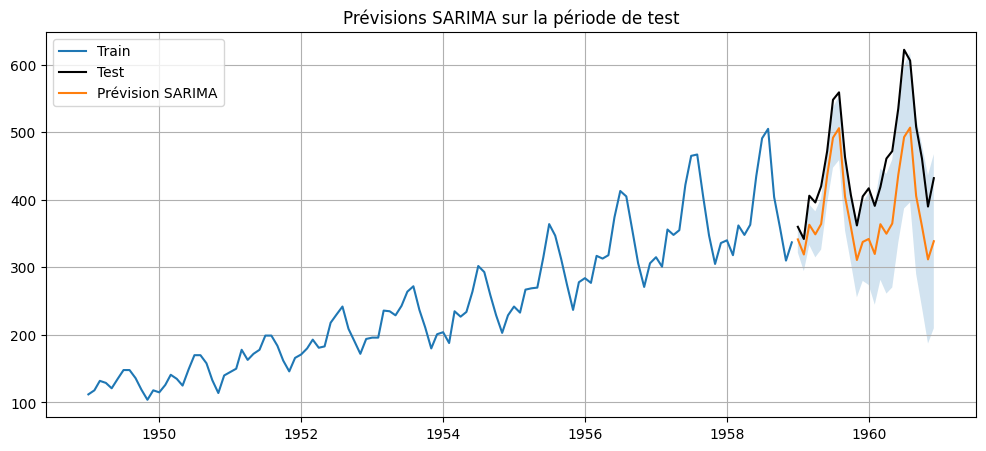

In [ ]:
forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

plt.plot(train, label="Train")
plt.plot(test, label="Test", color="black")
plt.plot(forecast_mean, label="Prévision SARIMA")
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    alpha=0.2
)
plt.title("Prévisions SARIMA sur la période de test")
plt.legend()
plt.show()

## Évaluation du modèle

On utilise ici deux métriques classiques :

- **MAE** : erreur absolue moyenne ;
- **RMSE** : racine de l'erreur quadratique moyenne.

La RMSE pénalise davantage les grosses erreurs.

In [ ]:
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE  : 69.90
RMSE : 75.63


## Prévision future

Une fois le modèle validé, on peut le réentraîner sur toute la série disponible, puis prévoir les périodes futures.

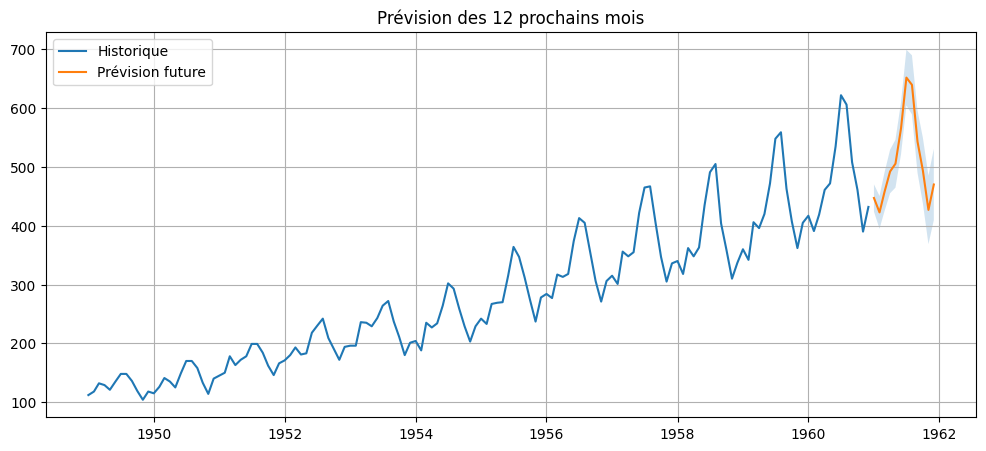

In [ ]:
final_model = SARIMAX(
    series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)
future_forecast = final_results.get_forecast(steps=12)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

plt.plot(series, label="Historique")
plt.plot(future_mean, label="Prévision future")
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2
)
plt.title("Prévision des 12 prochains mois")
plt.legend()
plt.show()